In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()  # picks up GROQ_API_KEY and LANGSMITH_* tracing vars from .env

In [3]:
from langchain_groq import ChatGroq
import os 

if os.getenv("GROQ_API_KEY"):
    print("the key is present")
else:
    print("the key is not present")

the key is present


In [4]:
llm=ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model="openai/gpt-oss-120b"
)
llm.invoke("I want to know the meaning of water").content

'**Water – A Quick Overview**\n\n| Aspect | What It Means |\n|--------|---------------|\n| **Basic definition** | A clear, tasteless, odorless, and nearly colorless liquid that is essential for most forms of life. |\n| **Chemical formula** | **H₂O** – each molecule is made of two hydrogen atoms covalently bonded to one oxygen atom. |\n| **Physical states** | Exists naturally as **solid (ice), liquid (water),** and **gas (water vapor/steam)** depending on temperature and pressure. |\n| **Key properties** | • High specific heat (stores heat)  <br>• High surface tension (forms droplets)  <br>• Excellent solvent (“universal solvent”)  <br>• Density anomaly: ice is less dense than liquid water, so it floats. |\n| **Biological role** | • Constitutes ~60\u202f% of the human body (varies by age and sex). <br>• Medium for biochemical reactions, transport of nutrients, temperature regulation, waste removal. |\n| **Environmental importance** | • Covers ~71\u202f% of Earth’s surface (≈\u202f361\u2

In [9]:
from typing import  TypedDict

class graph_schema(TypedDict):
    topic: str
    insta: str
    linkedIn: str
    twitter: str

In [10]:
def create_post_insta(state: graph_schema)-> graph_schema:

    topic=state['topic']

    post=llm.invoke(f"Create an Instagram post about {topic}").content
    state['insta']=post
    return {"insta": post}

In [11]:
def create_post_linkedIn(state: graph_schema) -> graph_schema:
    topic=state['topic']
    post=llm.invoke(f"Create a LinkedIn post about {topic}").content
    state['linkedIn']=post
    return {"linkedIn": post}

In [12]:
def create_post_twitter(state: graph_schema) -> graph_schema:
    topic=state['topic']
    post=llm.invoke(f"Create a Twitter post about {topic}").content
    state['twitter']=post
    return {"twitter": post}

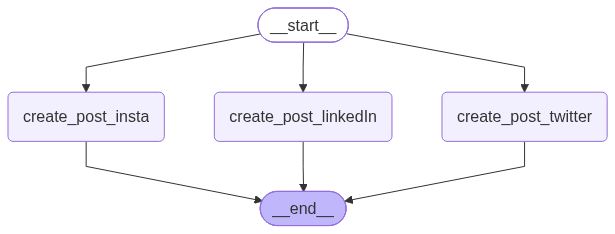

In [13]:
from langgraph.graph import START,END, StateGraph

graph=StateGraph(graph_schema)

graph.add_node("create_post_insta",create_post_insta)
graph.add_node("create_post_linkedIn",create_post_linkedIn)
graph.add_node("create_post_twitter",create_post_twitter)


graph.add_edge(START,"create_post_insta")
graph.add_edge(START,"create_post_linkedIn")
graph.add_edge(START,"create_post_twitter")
graph.add_edge("create_post_insta",END)
graph.add_edge("create_post_linkedIn",END)
graph.add_edge("create_post_twitter",END)

parallel_graph=graph.compile()
from IPython.display import Image, display

# You could see the errors with the below command
Image(parallel_graph.get_graph().draw_mermaid_png())

In [14]:
parallel_graph.invoke({
    "topic":"Artificial Intelligence is a boon for the society",
    "insta": "",
    "linkedIn": "",
    "twitter": ""
})

{'topic': 'Artificial Intelligence is a boon for the society',
 'insta': '**📸 Image Idea:**  \nA vibrant split‑screen photo – on the left, a diverse group of people (students, doctors, farmers, artists) using tech devices; on the right, sleek AI visuals (neural‑network graphics, a friendly robot, data streams). The background is bright, hopeful, and the colors are warm (orange, teal, and white).  \n\n---\n\n### 🌟 Caption\n\n> **Artificial Intelligence: A Gift to Humanity 🤖💡**  \n>  \n> From diagnosing diseases in minutes to powering clean‑energy grids, AI is quietly reshaping our world for the better. 🌍✨  \n>   \n> **Why it’s a *boon* for society:**  \n> 1️⃣ **Health & Wellness** – AI‑driven imaging catches illnesses early, giving patients a fighting chance.  \n> 2️⃣ **Education for All** – Personalized tutors adapt to each learner’s pace, breaking down barriers.  \n> 3️⃣ **Sustainable Future** – Smart farms, optimized logistics, and climate‑modeling help protect our planet.  \n> 4️⃣ *